# OCR model for reading Captchas

**Author:** [A_K_Nain](https://twitter.com/A_K_Nain)<br>
**Date created:** 2020/06/14<br>
**Last modified:** 2024/03/13<br>
**Description:** How to implement an OCR model using CNNs, RNNs and CTC loss.

## Introduction

This example demonstrates a simple OCR model built with the Functional API. Apart from
combining CNN and RNN, it also illustrates how you can instantiate a new layer
and use it as an "Endpoint layer" for implementing CTC loss. For a detailed
guide to layer subclassing, please check out
[this page](https://keras.io/guides/making_new_layers_and_models_via_subclassing/)
in the developer guides.

In [1]:
import tensorflow as tf
print(tf.__version__)
print(tf.test.is_built_with_cuda())
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.config.list_physical_devices('GPU'))

2.20.0
False
Num GPUs Available: 0
[]


## Setup

In [3]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

import tensorflow as tf
import keras
from keras import ops
from keras import layers

The dataset contains 1040 captcha files as `png` images. The label for each sample is a string,
the name of the file (minus the file extension).
We will map each character in the string to an integer for training the model. Similary,
we will need to map the predictions of the model back to strings. For this purpose
we will maintain two dictionaries, mapping characters to integers, and integers to characters,
respectively.

In [7]:

# Path to the data directory
data_dir = Path("../train/")

# Get list of all the images
images = sorted(list(map(str, list(data_dir.glob("*.png")))))
labels = [img.split(os.path.sep)[-1].split(".png")[0].split("-")[0] for img in images] # Get the ground truth labels from the file names
characters = set(char for label in labels for char in label)
characters = sorted(list(characters))

print("Number of images found: ", len(images))
print("Number of labels found: ", len(labels))
print("Number of unique characters: ", len(characters))
print("Characters present: ", characters)

# Batch size for training and validation
batch_size = 16 # originally 16

# Desired image dimensions
img_width = 250 # Full size is 500
img_height = 40 # Full size is 80

# Factor by which the image is going to be downsampled
# by the convolutional blocks. We will be using two
# convolution blocks and each block will have
# a pooling layer which downsample the features by a factor of 2.
# Hence total downsampling factor would be 4.
downsample_factor = 4

# Maximum length of any captcha in the dataset
max_length = max([len(label) for label in labels])


Number of images found:  8010
Number of labels found:  8010
Number of unique characters:  36
Characters present:  ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


## Preprocessing

In [10]:

# Mapping characters to integers
char_to_num = layers.StringLookup(vocabulary=list(characters), mask_token=None)

# Mapping integers back to original characters
num_to_char = layers.StringLookup(
    vocabulary=char_to_num.get_vocabulary(), mask_token=None, invert=True
)

def split_data(images, labels, train_size=0.9, shuffle=True):
    # 1. Get the total size of the dataset
    size = len(images)
    # 2. Make an indices array and shuffle it, if required
    indices = ops.arange(size)
    if shuffle:
        indices = keras.random.shuffle(indices)
    # 3. Get the size of training samples
    train_samples = int(size * train_size)
    # 4. Split data into training and validation sets
    x_train, y_train = images[indices[:train_samples]], labels[indices[:train_samples]]
    x_valid, y_valid = images[indices[train_samples:]], labels[indices[train_samples:]]
    return x_train, x_valid, y_train, y_valid


# Splitting data into training and validation sets
x_train, x_valid, y_train, y_valid = split_data(np.array(images), np.array(labels))


def encode_single_sample(img_path, label):
    # 1. Read image
    img = tf.io.read_file(img_path)
    # 2. Decode and convert to grayscale
    img = tf.io.decode_png(img, channels=1)
    # 3. Convert to float32 in [0, 1] range
    img = tf.image.convert_image_dtype(img, tf.float32)

    # --- DARKEN NON-WHITE PIXELS ---
    # Create a mask of non-white pixels (anything < 1.0)
    mask = img < 1.0
    darken_factor = 0.2
    # Multiply only those pixels by the darken factor
    img = tf.where(mask, img * darken_factor, img)

    # --- CENTER CROP HORIZONTALLY ---
    img_shape = tf.shape(img)  # [height, width, channels]
    current_width = img_shape[1]
    crop_width = 500
    # If image is wider than crop_width
    def crop():
        start = (current_width - crop_width) // 2
        return tf.image.crop_to_bounding_box(img, 0, start, img_shape[0], crop_width)
    # If image is narrower than crop_width, just return the original
    img = tf.cond(current_width > crop_width, crop, lambda: img)
    
    # 4. Resize to the desired size
    img = ops.image.resize(img, [img_height, img_width]) # After resizing, your image tensor has shape: (img_height, img_width, 1)
    # 5. Transpose the image because we want the time
    # dimension to correspond to the width of the image.
    img = ops.transpose(img, axes=[1, 0, 2]) # Now the image shape is (img_width, img_height, 1) (swapped width and height)
    # 6. Map the characters in label to numbers
    label = char_to_num(tf.strings.unicode_split(label, input_encoding="UTF-8"))
    # 7. Return a dict as our model is expecting two inputs
    return {"image": img, "label": label}


## Create `Dataset` objects

In [13]:

train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = (
    train_dataset.map(encode_single_sample, num_parallel_calls=tf.data.AUTOTUNE)
    .padded_batch(
        batch_size,
        padded_shapes=(
            {"image": [img_width, img_height, 1], "label": [None]}
        ),
        padding_values=(
            {"image": 0.0, "label": tf.constant(0, dtype=tf.int64)}
        )
    )
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

validation_dataset = tf.data.Dataset.from_tensor_slices((x_valid, y_valid))
validation_dataset = (
    validation_dataset.map(encode_single_sample, num_parallel_calls=tf.data.AUTOTUNE)
    .padded_batch(
        batch_size,
        padded_shapes=(
            {"image": [img_width, img_height, 1], "label": [None]}
        ),
        padding_values=(
            {"image": 0.0, "label": tf.constant(0, dtype=tf.int64)}
        )
    )
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

## Visualize the data

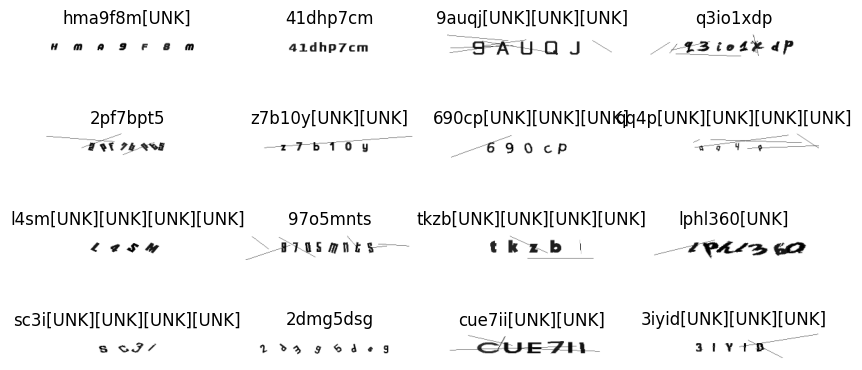

In [16]:

_, ax = plt.subplots(4, 4, figsize=(10, 5))
for batch in train_dataset.take(1):
    images = batch["image"]
    labels = batch["label"]
    for i in range(16):
        img = (images[i] * 255).numpy().astype("uint8")
        label = tf.strings.reduce_join(num_to_char(labels[i])).numpy().decode("utf-8")
        ax[i // 4, i % 4].imshow(img[:, :, 0].T, cmap="gray")
        ax[i // 4, i % 4].set_title(label)
        ax[i // 4, i % 4].axis("off")
plt.show()

## Model

In [19]:

def ctc_batch_cost(y_true, y_pred, input_length, label_length): 
    # input_length: Number of time steps (width after CNN+RNN layers).
    # label_length: Number of characters in each true label.

    # Clean up lengths
    # label_length and input_length often come with an extra dimension (e.g., shape [batch, 1]).
    # ops.squeeze(..., axis=-1) removes that last dimension so you just get [batch].
    # ops.cast(..., dtype="int32") ensures they are integer tensors, since CTC expects int32.
    label_length = ops.cast(ops.squeeze(label_length, axis=-1), dtype="int32")
    input_length = ops.cast(ops.squeeze(input_length, axis=-1), dtype="int32") # Example: If input_length = [[25], [27]] → becomes [25, 27].

    # (See function definition of ctc_label_dense_to_sparse below)
    sparse_labels = ops.cast(
        ctc_label_dense_to_sparse(y_true, label_length), dtype="int32"
    )

    # y_pred comes from the model with shape: [batch_size, time_steps, num_classes]
    # CTC expects: [time_steps, batch_size, num_classes]
    # So, transpose the first 2 axes.
    # Then take the log of probabilities (since CTC operates on log-probabilities). keras.backend.epsilon() avoids log(0) (numerical stability).
    y_pred = ops.log(ops.transpose(y_pred, axes=[1, 0, 2]) + keras.backend.epsilon())

    return ops.expand_dims(
        tf.compat.v1.nn.ctc_loss( # tf.compat.v1.nn.ctc_loss computes the per-example CTC loss.
            inputs=y_pred, 
            labels=sparse_labels, 
            sequence_length=input_length # tells CTC how long each prediction actually is.
        ),
        1,
    ) # the result has shape [batch], so we use: ops.expand_dims(..., 1), to make it [batch, 1] — consistent with Keras’s loss expectations.


# Helper that converts a dense (padded) label tensor into a sparse representation — which is required by TensorFlow’s ctc_loss.
# Your labels (y_true) are typically padded to a fixed length because batches need uniform shapes.
# But CTC loss expects labels as a SparseTensor, because only the real character indices matter (zeros/padding are ignored).
# So this function converts the dense padded labels → a sparse representation containing only valid characters.
# Example: 
# If "cat", "hi", "doge", then inputs are possibly
# labels = tf.constant([
#    [12, 1, 20, 0, 0],
#    [8, 9, 0, 0, 0],
#    [4, 15, 7, 5, 0]
#], dtype=tf.int32)
# label_lengths = tf.constant([[3], [2], [4]], dtype=tf.int32)
def ctc_label_dense_to_sparse(labels, label_lengths): 
    # Get label shape and batch info
    # If labels has shape [batch, max_label_len],
    # then:
    # label_shape[0] = number of batches (each batch is 1 "word")
    # label_shape[1] = max number of labels
    label_shape = ops.shape(labels)
    num_batches_tns = ops.stack([label_shape[0]])
    max_num_labels_tns = ops.stack([label_shape[1]])

    # For each batch item, it creates a mask of shape [max_label_len] where:
    # True for indices < actual label length
    # False for padding positions
    # label_lengths = [3, 2]
    # Example:
    # dense_mask =
    # [
    #    [True, True, True, False, False],  # 3 valid chars
    #    [True, True, False, False, False]  # 2 valid chars
    # ]
    def range_less_than(old_input, current_input):
        return ops.expand_dims(ops.arange(ops.shape(old_input)[1]), 0) < tf.fill(
            max_num_labels_tns, current_input
        )
    init = ops.cast(tf.fill([1, label_shape[1]], 0), dtype="bool")
    dense_mask = tf.compat.v1.scan(
        range_less_than, label_lengths, initializer=init, parallel_iterations=1
    )
    dense_mask = dense_mask[:, 0, :]

    # label_shape[1] = max number of labels
    # ops.arange(0, label_shape[1]) = [0, 1, 2, 3, 4] (column indices)
    # After tiling, it repeats that for each batch
    # Then boolean_mask with dense_mask that we made previously will remove padded entries
    # Example output: label_ind = [0,1,2,0,1]   # only valid label indices
    label_array = ops.reshape(
        ops.tile(ops.arange(0, label_shape[1]), num_batches_tns), label_shape
    )
    label_ind = tf.compat.v1.boolean_mask(label_array, dense_mask)

    # This does the same but for the batch dimension:
    # Creates a [batch, label_len] grid of batch IDs
    # Keeps only the ones corresponding to True in the mask
    # Example output: batch_ind = [0,0,0,1,1] (saying the first 3 indices belong to batch 0, then the next 2 belong to batch 1)
    batch_array = ops.transpose(
        ops.reshape(
            ops.tile(ops.arange(0, label_shape[0]), max_num_labels_tns),
            tf.reverse(label_shape, [0]),
        )
    )
    batch_ind = tf.compat.v1.boolean_mask(batch_array, dense_mask)

    # This stacks batch_ind and label_ind to make pairs:
    # Example output: indices = [[0,0],[0,1],[0,2],[1,0],[1,1]]
    # These represent the location of the numeric labels we want
    indices = ops.transpose(
        ops.reshape(ops.concatenate([batch_ind, label_ind], axis=0), [2, -1])
    )

    # Pulls the actual numeric labels (e.g., character indices) from the dense tensor at those positions:
    vals_sparse = tf.compat.v1.gather_nd(labels, indices)

    # Build the SparseTensor
    # SparseTensor(
    #     indices = [[0,0],[0,1],[0,2],[1,0],[1,1]],
    #     values  = [12,5,7,9,14],
    #     dense_shape = [2,5]
    #   )
    return tf.SparseTensor(
        ops.cast(indices, dtype="int64"),
        vals_sparse,
        ops.cast(label_shape, dtype="int64")
    )

# Custom CTC Loss layer
class CTCLayer(layers.Layer):
    def __init__(self, name=None):
        super().__init__(name=name)
        self.loss_fn = ctc_batch_cost

    # This is what runs when the layer is called during the forward pass.
    # y_true: the ground-truth label sequences (encoded characters)
    # y_pred: the model’s output — a 3D tensor of predicted character probabilities (shape = [batch, time_steps, num_characters])
    def call(self, y_true, y_pred):
        # Compute the training-time loss value and add it
        # to the layer using `self.add_loss()`.
        batch_len = ops.cast(ops.shape(y_true)[0], dtype="int64")
        input_length = ops.cast(ops.shape(y_pred)[1], dtype="int64")
        label_length = ops.cast(ops.shape(y_true)[1], dtype="int64")

        # These create two column vectors shaped [batch, 1] where every row has the same value.
        # Example:
        # If batch_len=3, input_length=25, label_length=10
        # input_length = [[25],[25],[25]]
        # label_length = [[10],[10],[10]]
        # These are needed because ctc_batch_cost() expects lengths per sample (even if all are identical).
        input_length = input_length * ops.ones(shape=(batch_len, 1), dtype="int64")
        label_length = label_length * ops.ones(shape=(batch_len, 1), dtype="int64")

        # Keras layers can register losses using self.add_loss(). 
        # Keras automatically sums all added losses in the model (including this one) — you don’t have to pass a separate loss function.
        loss = self.loss_fn(y_true, y_pred, input_length, label_length)
        self.add_loss(loss)

        # At test time, just return the computed predictions
        return y_pred


def build_model():
    # Inputs to the model
    input_img = layers.Input(
        shape=(img_width, img_height, 1), name="image", dtype="float32"
    )
    labels = layers.Input(name="label", shape=(None,), dtype="float32")

    # First conv block
    x = layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        kernel_initializer="he_normal",
        padding="same", # Retain original image dimensions, pad with 0 during convolution if needed
        name="Conv1",
    )(input_img)
    x = layers.MaxPooling2D((2, 2), name="pool1")(x) # Max pool, increase robustness to noise

    # Second conv block
    x = layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        kernel_initializer="he_normal",
        padding="same",
        name="Conv2",
    )(x)
    x = layers.MaxPooling2D((2, 2), name="pool2")(x)

    # We have used two max pool with pool size and strides 2.
    # Hence, downsampled feature maps are 4x smaller. The number of
    # filters in the last layer is 64. Reshape accordingly before
    # passing the output to the RNN part of the model
    new_shape = ((img_width // 4), (img_height // 4) * 64)
    x = layers.Reshape(target_shape=new_shape, name="reshape")(x)
    x = layers.Dense(64, activation="relu", name="dense1")(x)
    x = layers.Dropout(0.2)(x)

    # RNNs
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.25))(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.25))(x)

    # Output layer
    x = layers.Dense(
        len(char_to_num.get_vocabulary()) + 1, activation="softmax", name="dense2"
    )(x)

    # Add CTC layer for calculating CTC loss at each step
    output = CTCLayer(name="ctc_loss")(labels, x)

    # Define the model
    model = keras.models.Model(
        inputs=[input_img, labels], outputs=output, name="ocr_model_v1"
    )
    # Optimizer
    opt = keras.optimizers.Adam()
    # Compile the model and return
    model.compile(optimizer=opt)
    return model


# Get the model
model = build_model()
model.summary()

Model: "ocr_model_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)            │ (None, 250, 40, 1)        │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 250, 40, 32)       │             320 │ image[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1 (MaxPooling2D)          │ (None, 125, 20, 32)       │               0 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv2 (Conv2D)                │ (None, 125, 20, 64)       │          18,496 │ pool1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool2 (MaxPooling2D)          │ (None, 62, 10, 64)        │               0 │ Conv2[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape (Reshape)             │ (None, 62, 640)           │               0 │ pool2[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense1 (Dense)                │ (None, 62, 64)            │          41,024 │ reshape[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 62, 64)            │               0 │ dense1[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional (Bidirectional) │ (None, 62, 256)           │         197,632 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional_1               │ (None, 62, 128)           │         164,352 │ bidirectional[0][0]        │
│ (Bidirectional)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ label (InputLayer)            │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense2 (Dense)                │ (None, 62, 38)            │           4,902 │ bidirectional_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ ctc_loss (CTCLayer)           │ (None, 62, 38)            │               0 │ label[0][0], dense2[0][0]  │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 426,726 (1.63 MB)

 Trainable params: 426,726 (1.63 MB)

 Non-trainable params: 0 (0.00 B)

## Training

In [22]:

# TODO restore epoch count.
epochs = 100
early_stopping_patience = 10 # If model has no improvement after 10 epochs, stop training
# Add early stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss", 
    patience=early_stopping_patience, 
    restore_best_weights=True # If early stopping activated, then restore the best weights obtained
)

# Train the model
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=epochs,
    callbacks=[early_stopping],
)


Epoch 1/100
451/451 ━━━━━━━━━━━━━━━━━━━━ 66s 124ms/step - loss: 431.4976 - val_loss: 402.0021
Epoch 2/100
451/451 ━━━━━━━━━━━━━━━━━━━━ 79s 117ms/step - loss: 392.2574 - val_loss: 392.4807
Epoch 3/100
451/451 ━━━━━━━━━━━━━━━━━━━━ 83s 119ms/step - loss: 387.9032 - val_loss: 390.2285
Epoch 4/100
451/451 ━━━━━━━━━━━━━━━━━━━━ 80s 114ms/step - loss: 385.6571 - val_loss: 387.5468
Epoch 5/100
451/451 ━━━━━━━━━━━━━━━━━━━━ 50s 111ms/step - loss: 383.2125 - val_loss: 384.8065
Epoch 6/100
451/451 ━━━━━━━━━━━━━━━━━━━━ 50s 111ms/step - loss: 380.6843 - val_loss: 381.6525
Epoch 7/100
451/451 ━━━━━━━━━━━━━━━━━━━━ 82s 111ms/step - loss: 377.8188 - val_loss: 380.4048
Epoch 8/100
451/451 ━━━━━━━━━━━━━━━━━━━━ 84s 116ms/step - loss: 374.6069 - val_loss: 375.6964
Epoch 9/100
451/451 ━━━━━━━━━━━━━━━━━━━━ 82s 117ms/step - loss: 371.0255 - val_loss: 375.0943
Epoch 10/100
451/451 ━━━━━━━━━━━━━━━━━━━━ 83s 119ms/step - loss: 369.4364 - val_loss: 373.9525
Epoch 11/100
451/451 ━━━━━━━━━━━━━━━━━━━━ 82s 118ms/step - 

### Plot Training Curves

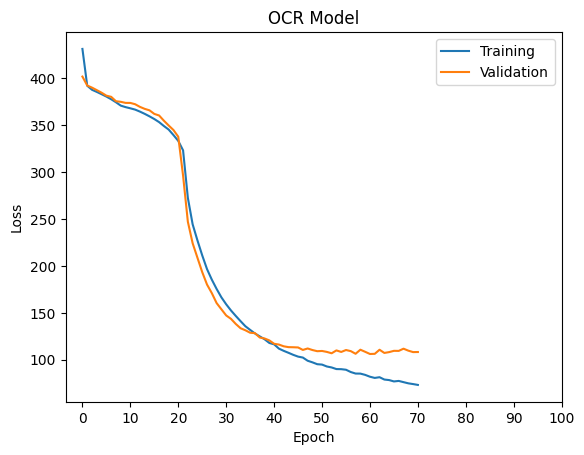

In [24]:
# Plot the loss of the model during training
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xticks(range(0, epochs+1,10))
plt.title("OCR Model")
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show()

## Inference

You can use the trained model hosted on [Hugging Face Hub](https://huggingface.co/keras-io/ocr-for-captcha)
and try the demo on [Hugging Face Spaces](https://huggingface.co/spaces/keras-io/ocr-for-captcha).

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)                   │ (None, 250, 40, 1)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv1 (Conv2D)                       │ (None, 250, 40, 32)         │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling2D)                 │ (None, 125, 20, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv2 (Conv2D)                       │ (None, 125, 20, 64)         │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool2 (MaxPooling2D)                 │ (None, 62, 10, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 62, 640)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense1 (Dense)                       │ (None, 62, 64)              │          41,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 62, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 62, 256)             │         197,632 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 62, 128)             │         164,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense2 (Dense)                       │ (None, 62, 38)              │           4,902 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 426,726 (1.63 MB)

 Trainable params: 426,726 (1.63 MB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


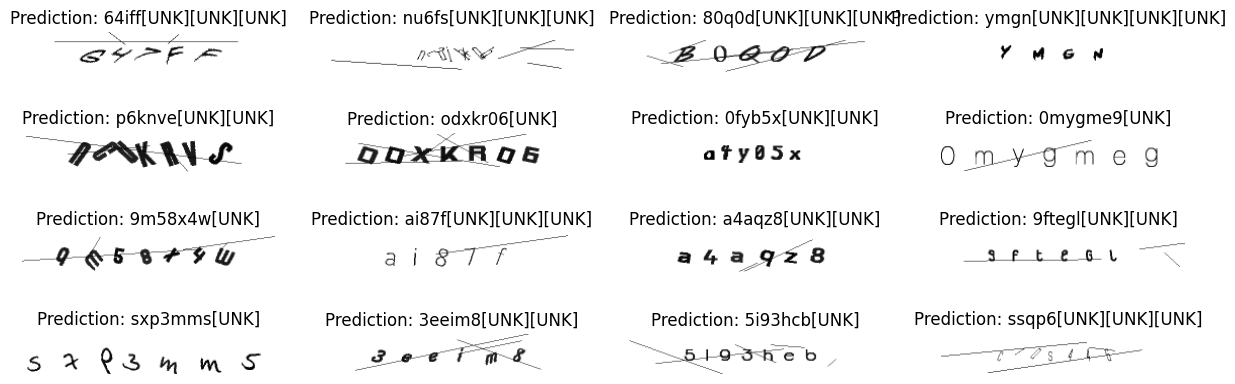

In [27]:
# Each “time step” predicts a probability distribution over possible characters.
# But these predictions include “blank” tokens and may repeat characters, e.g.: "-", "c", "a", "a", "t", "t", "-"
# CTC decoding merges duplicates and removes blanks → "cat".
def ctc_decode(y_pred, input_length, greedy=True, beam_width=100, top_paths=1):
    input_shape = ops.shape(y_pred)
    num_samples, num_steps = input_shape[0], input_shape[1]
    # So if you predict 16 images each with 25 time steps, num_samples=16, num_steps=25.

    # Transposes from shape [batch, time, classes] → [time, batch, classes], which is the format required by TensorFlow’s CTC decoders.
    y_pred = ops.log(ops.transpose(y_pred, axes=[1, 0, 2]) + keras.backend.epsilon())
    # CTC decoders need to know how long each predicted sequence is. Usually, this is the same for all in the batch (e.g., [25, 25, 25, ...]).
    input_length = ops.cast(input_length, dtype="int32")

    # There are two modes: greedy decoding or beam search.
    # Greedy (fast, simple):
    # At each time step, pick the most probable character (argmax). Then collapse repeats and remove blanks.
    # Fast, but may not always give the best result.
    # Beam Search (slower, more accurate):
    # Keeps multiple likely paths (“beam width”) at each step. Returns top_paths best sequences.
    # More accurate, especially for ambiguous images or long texts.
    if greedy:
        (decoded, log_prob) = tf.nn.ctc_greedy_decoder(
            inputs=y_pred, sequence_length=input_length
        )
    else:
        (decoded, log_prob) = tf.compat.v1.nn.ctc_beam_search_decoder(
            inputs=y_pred,
            sequence_length=input_length,
            beam_width=beam_width,
            top_paths=top_paths,
        )

    # Convert sparse results to dense tensors
    # Each st (sparse tensor) contains only the valid characters for each sample.
    # Convert it to a dense tensor of shape [batch, time], filling missing positions with -1 (for “no character”).
    decoded_dense = []
    for st in decoded:
        st = tf.SparseTensor(st.indices, st.values, (num_samples, num_steps))
        decoded_dense.append(tf.sparse.to_dense(sp_input=st, default_value=-1))
    return (decoded_dense, log_prob)


# Get the prediction model by extracting layers till the output layer
prediction_model = keras.models.Model(
    model.input[0], model.get_layer(name="dense2").output
)
prediction_model.summary()


# A utility function to decode the output of the network
# After your model predicts raw probabilities, decode_batch_predictions() turns those into actual text strings (like "HELLO").
def decode_batch_predictions(pred):
    # Example:
    # pred.shape = (32, 25, 41)  # 32 samples, 25 time steps, 41 characters
    # input_len = np.ones(32) * 25  # [25, 25, 25, ...]
    input_len = np.ones(pred.shape[0]) * pred.shape[1]

    # Run our ctc_decode() helper function.
    # Use greedy search. For complex tasks, you can use beam search
    results = ctc_decode(pred, input_length=input_len, greedy=True)[0][0][
        :, :max_length
    ]
    # Each row of results contains integer character IDs, e.g.:
    # [[ 3, 1, 20, -1, -1],
    # [19,  0, 12,  5,  -1],
    # ...]
    # (-1 means “no character” / padding)
    
    # Iterate over the results and get back the text
    output_text = []
    # This loop turns each numeric sequence into readable text:
    # num_to_char(res) maps each integer ID → character (e.g., 0 → 'a', 1 → 'b', etc.)
    # tf.strings.reduce_join() joins them into one string tensor (e.g. 'cat')
    # .numpy().decode('utf-8') converts it from TensorFlow bytes to a Python string
    # Append the result to a Python list
    for res in results:
        res = tf.strings.reduce_join(num_to_char(res)).numpy().decode("utf-8")
        output_text.append(res)
        
    return output_text


#  Let's check results on some validation samples
for batch in validation_dataset.take(1):
    batch_images = batch["image"][:16]
    batch_labels = batch["label"][:16]

    preds = prediction_model.predict(batch_images) # Get raw predictions from models
    pred_texts = decode_batch_predictions(preds) # Get decoded prediction texts (python list of strings)

    orig_texts = []
    for label in batch_labels:
        label = tf.strings.reduce_join(num_to_char(label)).numpy().decode("utf-8")
        orig_texts.append(label)

    _, ax = plt.subplots(4, 4, figsize=(15, 5))
    for i in range(len(pred_texts)):
        img = (batch_images[i, :, :, 0] * 255).numpy().astype(np.uint8)
        img = img.T
        title = f"Prediction: {pred_texts[i]}"
        ax[i // 4, i % 4].imshow(img, cmap="gray")
        ax[i // 4, i % 4].set_title(title)
        ax[i // 4, i % 4].axis("off")
plt.show()